In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data

In [28]:
# Directories for training and testing data
train_dir = "/content/drive/MyDrive/Tumour-20260617T101606Z-3-001/Tumour/train"
test_dir = "/content/drive/MyDrive/Tumour-20260617T101606Z-3-001/Tumour/test"

# Load and shuffle the train data
train_paths = []
train_labels = []
for label_name in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label_name)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            train_paths.append(os.path.join(label_path, image))
            train_labels.append(label_name)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label_name in os.listdir(test_dir):
    label_path = os.path.join(test_dir, label_name)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            test_paths.append(os.path.join(label_path, image))
            test_labels.append(label_name)

test_paths, test_labels = shuffle(test_paths, test_labels)

In [29]:
LABELS = sorted(list(np.unique(train_labels)))
print(f"Defined class labels: {LABELS}")

Defined class labels: [np.str_('glioma'), np.str_('meningioma'), np.str_('no_tumor'), np.str_('pituitary')]


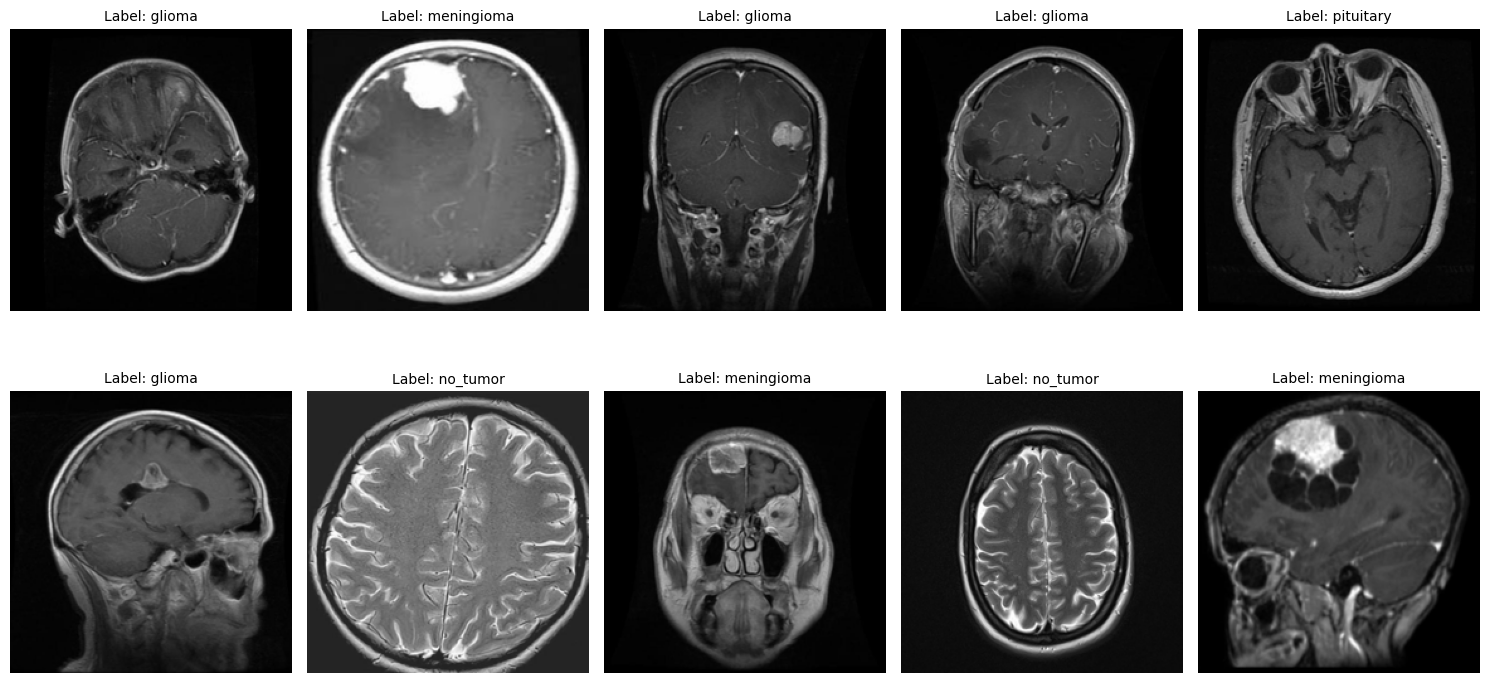

In [30]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


In [31]:
import numpy as np
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    # Use the globally defined LABELS for consistent encoding
    encoded = [LABELS.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

In [32]:
# MODEL:

## WE ARE USING VGG16 FOR TRANSFER LEARNING.

In [33]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(LABELS), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - loss: 0.6519 - sparse_categorical_accuracy: 0.7429
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - loss: 0.3170 - sparse_categorical_accuracy: 0.8800
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.2265 - sparse_categorical_accuracy: 0.9140
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.1549 - sparse_categorical_accuracy: 0.9463
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.1219 - sparse_categorical_accuracy: 0.9576


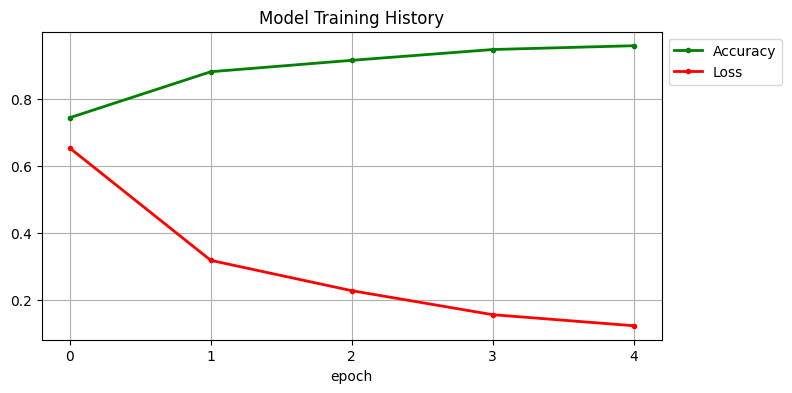

In [34]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [35]:
# Model Classification Report

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        80
           1       0.88      0.90      0.89        63
           2       0.93      0.84      0.88        49
           3       0.96      0.94      0.95        54

    accuracy                           0.92       246
   macro avg       0.92      0.91      0.92       246
weighted avg       0.92      0.92      0.92       246



In [37]:
# Model Confusion Plot

Confusion Matrix:
[[77  3  0  0]
 [ 2 57  3  1]
 [ 4  3 41  1]
 [ 1  2  0 51]]


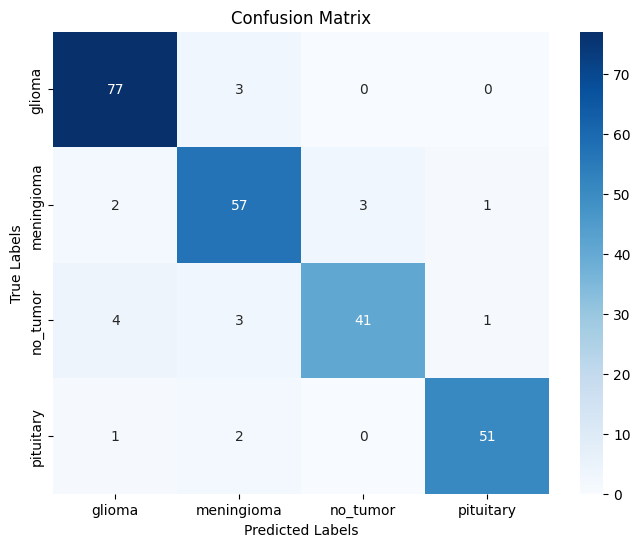

In [38]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [39]:
# Roc Curve Plot


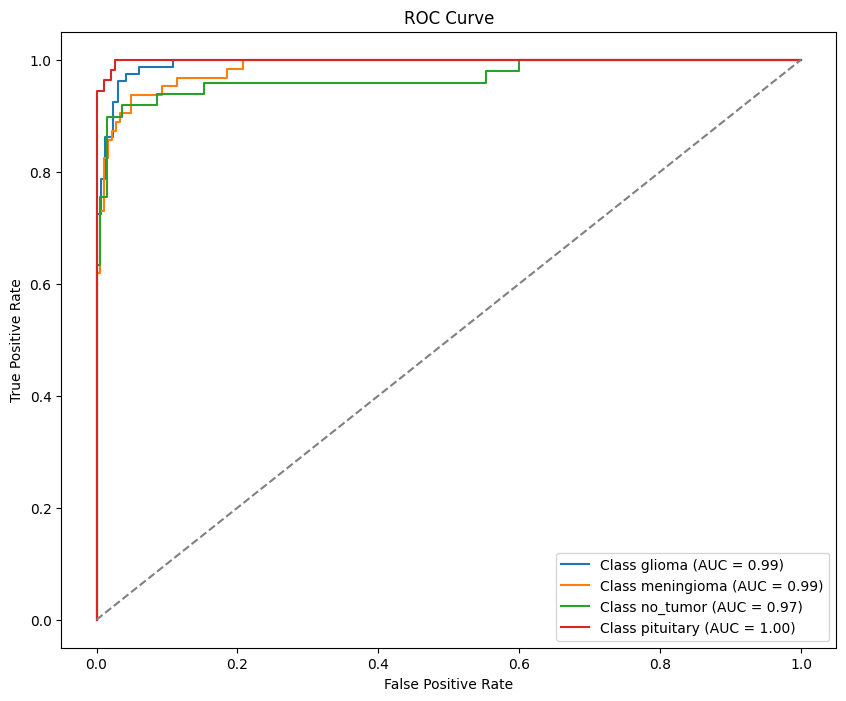

In [40]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(LABELS)))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(LABELS)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(LABELS)):
    plt.plot(fpr[i], tpr[i], label=f'Class {LABELS[i]} (AUC = {roc_auc[i]:.2f})') # Use actual label name here

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Model Comparison: ResNet50

In [41]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

# ResNet50 Model Architecture
# Define the input shape for ResNet50, ensuring it's at least 32x32
# ResNet50 generally prefers input sizes like (224, 224, 3) or (128, 128, 3) for smaller datasets like this.
IMAGE_SIZE_RESNET = 128 # Using the same image size for consistency with VGG16

base_model_resnet = ResNet50(input_shape=(IMAGE_SIZE_RESNET, IMAGE_SIZE_RESNET, 3), include_top=False, weights='imagenet')

# Freeze all layers of the ResNet50 base model
for layer in base_model_resnet.layers:
    layer.trainable = False

# Build the final model on top of ResNet50
model_resnet = Sequential()
model_resnet.add(Input(shape=(IMAGE_SIZE_RESNET, IMAGE_SIZE_RESNET, 3)))  # Input layer
model_resnet.add(base_model_resnet)  # Add ResNet50 base model
model_resnet.add(GlobalAveragePooling2D()) # Use GlobalAveragePooling2D for ResNet
model_resnet.add(Dropout(0.3))  # Dropout layer for regularization
model_resnet.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model_resnet.add(Dropout(0.2))  # Dropout layer for regularization
model_resnet.add(Dense(len(LABELS), activation='softmax'))  # Output layer with softmax activation

# Compile the ResNet50 model
model_resnet.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='sparse_categorical_crossentropy',
                     metrics=['sparse_categorical_accuracy'])

print("ResNet50 model built and compiled.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 model built and compiled.


### Training ResNet50 Model

In [42]:
# Train the ResNet50 model
history_resnet = model_resnet.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                                  epochs=epochs, steps_per_epoch=steps)

print("ResNet50 model training complete.")

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - loss: 1.4662 - sparse_categorical_accuracy: 0.3000
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 1.4028 - sparse_categorical_accuracy: 0.3099
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 1.3689 - sparse_categorical_accuracy: 0.3493
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 1.3330 - sparse_categorical_accuracy: 0.3803
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 1.2934 - sparse_categorical_accuracy: 0.4143
ResNet50 model training complete.


### ResNet50 Training History

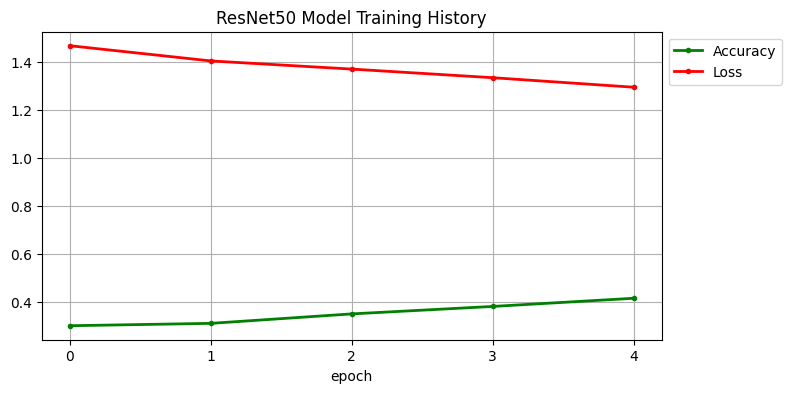

In [43]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history_resnet.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_resnet.history['loss'], '.r-', linewidth=2)
plt.title('ResNet50 Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### ResNet50 Model Evaluation

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 701ms/step
ResNet50 Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.99      0.60        80
           1       1.00      0.05      0.09        63
           2       0.78      0.43      0.55        49
           3       0.77      0.44      0.56        54

    accuracy                           0.52       246
   macro avg       0.74      0.48      0.45       246
weighted avg       0.72      0.52      0.45       246


ResNet50 Confusion Matrix:
[[79  0  1  0]
 [53  3  3  4]
 [25  0 21  3]
 [28  0  2 24]]


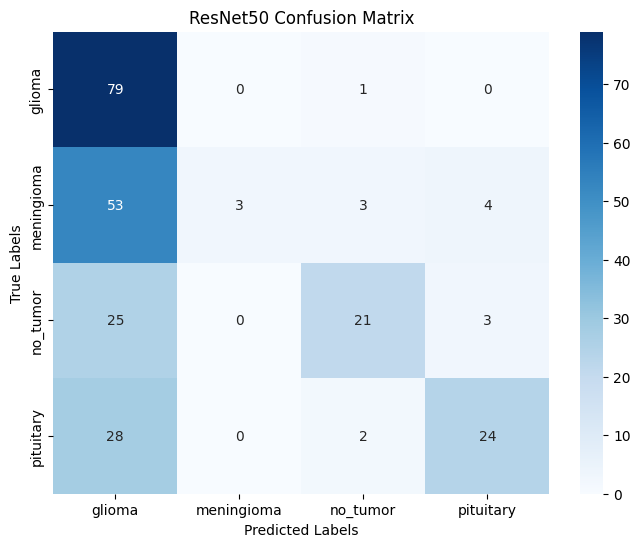

In [44]:
# 1. Prediction on test data using ResNet50
test_images_resnet = open_images(test_paths)  # Load and augment test images
test_labels_encoded_resnet = encode_label(test_labels)  # Encode the test labels

# Predict using the trained ResNet50 model
test_predictions_resnet = model_resnet.predict(test_images_resnet)

# 2. Classification Report for ResNet50
print("ResNet50 Classification Report:")
print(classification_report(test_labels_encoded_resnet, np.argmax(test_predictions_resnet, axis=1)))

# 3. Confusion Matrix for ResNet50
conf_matrix_resnet = confusion_matrix(test_labels_encoded_resnet, np.argmax(test_predictions_resnet, axis=1))
print("\nResNet50 Confusion Matrix:")
print(conf_matrix_resnet)

# Plot the ResNet50 Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_resnet, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

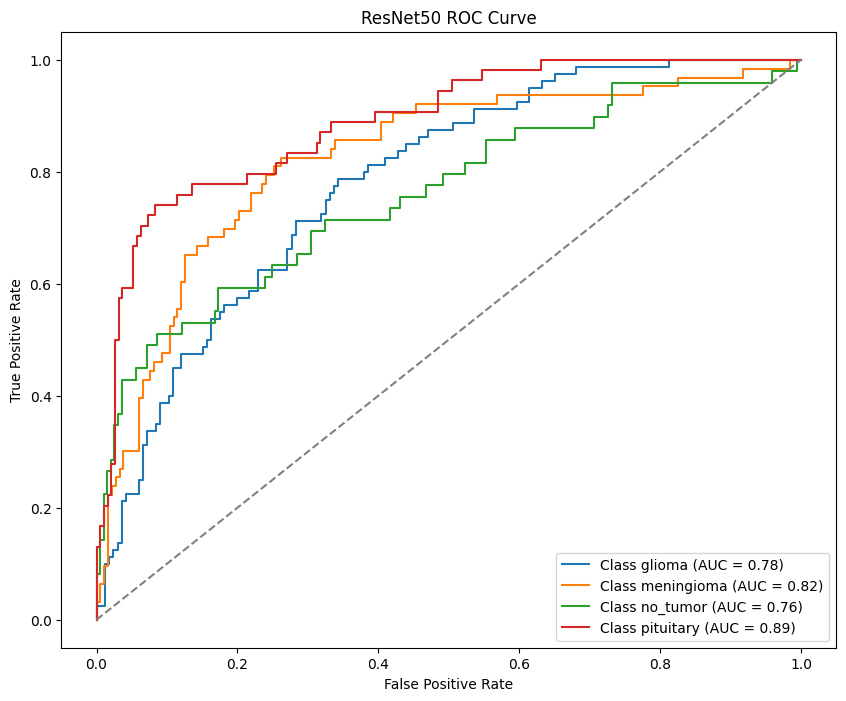

In [45]:
# 4. ROC Curve and AUC for ResNet50
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin_resnet = label_binarize(test_labels_encoded_resnet, classes=np.arange(len(LABELS)))
test_predictions_bin_resnet = test_predictions_resnet  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr_resnet, tpr_resnet, roc_auc_resnet = {}, {}, {}
for i in range(len(LABELS)):
    fpr_resnet[i], tpr_resnet[i], _ = roc_curve(test_labels_bin_resnet[:, i], test_predictions_bin_resnet[:, i])
    roc_auc_resnet[i] = auc(fpr_resnet[i], tpr_resnet[i])

# Plot ROC curve for ResNet50
plt.figure(figsize=(10, 8))
for i in range(len(LABELS)):
    plt.plot(fpr_resnet[i], tpr_resnet[i], label=f'Class {LABELS[i]} (AUC = {roc_auc_resnet[i]:.2f})') # Use actual label name here

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ResNet50 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Model Comparison: MobileNet

In [46]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D

# MobileNet Model Architecture
# Define the input shape for MobileNet
IMAGE_SIZE_MOBILENET = 128 # Using the same image size for consistency

base_model_mobilenet = MobileNet(input_shape=(IMAGE_SIZE_MOBILENET, IMAGE_SIZE_MOBILENET, 3), include_top=False, weights='imagenet')

# Freeze all layers of the MobileNet base model
for layer in base_model_mobilenet.layers:
    layer.trainable = False

# Build the final model on top of MobileNet
model_mobilenet = Sequential()
model_mobilenet.add(Input(shape=(IMAGE_SIZE_MOBILENET, IMAGE_SIZE_MOBILENET, 3)))  # Input layer
model_mobilenet.add(base_model_mobilenet)  # Add MobileNet base model
model_mobilenet.add(GlobalAveragePooling2D()) # Use GlobalAveragePooling2D for MobileNet
model_mobilenet.add(Dropout(0.3))  # Dropout layer for regularization
model_mobilenet.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model_mobilenet.add(Dropout(0.2))  # Dropout layer for regularization
model_mobilenet.add(Dense(len(LABELS), activation='softmax'))  # Output layer with softmax activation

# Compile the MobileNet model
model_mobilenet.compile(optimizer=Adam(learning_rate=0.0001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['sparse_categorical_accuracy'])

print("MobileNet model built and compiled.")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNet model built and compiled.


### Training MobileNet Model

In [47]:
# Train the MobileNet model
history_mobilenet = model_mobilenet.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                                        epochs=epochs, steps_per_epoch=steps)

print("MobileNet model training complete.")

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - loss: 1.6185 - sparse_categorical_accuracy: 0.3637
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - loss: 0.9196 - sparse_categorical_accuracy: 0.6340
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.6920 - sparse_categorical_accuracy: 0.7266
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.5780 - sparse_categorical_accuracy: 0.7869
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.4839 - sparse_categorical_accuracy: 0.8191
MobileNet model training complete.


### MobileNet Training History

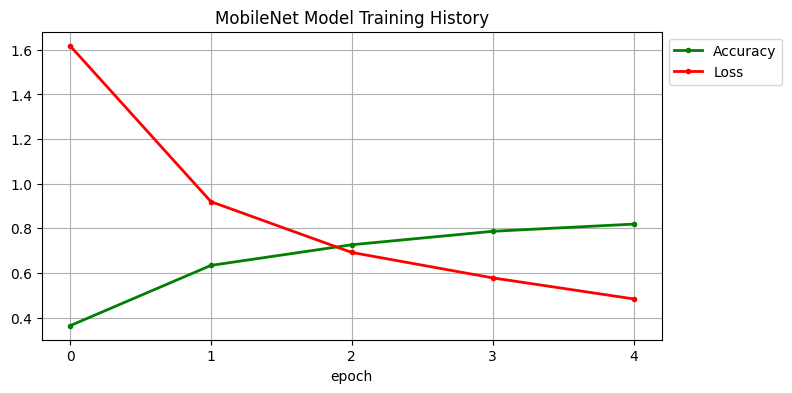

In [48]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history_mobilenet.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_mobilenet.history['loss'], '.r-', linewidth=2)
plt.title('MobileNet Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### MobileNet Model Evaluation

8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step
MobileNet Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88        80
           1       0.84      0.73      0.78        63
           2       0.95      0.76      0.84        49
           3       0.85      0.96      0.90        54

    accuracy                           0.85       246
   macro avg       0.87      0.85      0.85       246
weighted avg       0.86      0.85      0.85       246


MobileNet Confusion Matrix:
[[75  5  0  0]
 [10 46  2  5]
 [ 5  3 37  4]
 [ 1  1  0 52]]


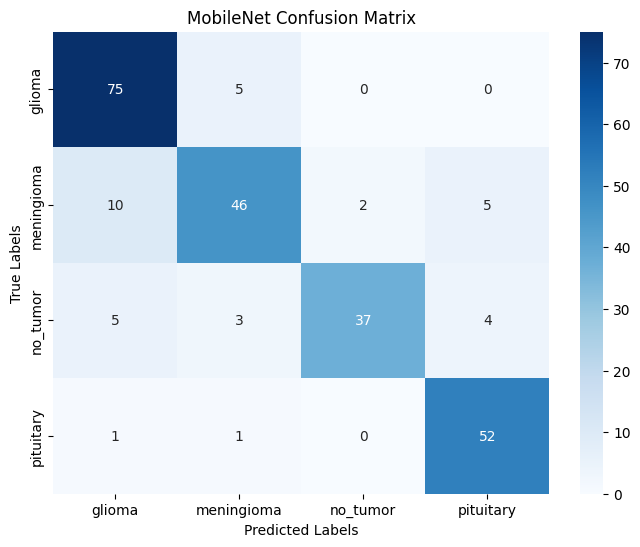

In [49]:
# 1. Prediction on test data using MobileNet
test_images_mobilenet = open_images(test_paths)  # Load and augment test images
test_labels_encoded_mobilenet = encode_label(test_labels)  # Encode the test labels

# Predict using the trained MobileNet model
test_predictions_mobilenet = model_mobilenet.predict(test_images_mobilenet)

# 2. Classification Report for MobileNet
print("MobileNet Classification Report:")
print(classification_report(test_labels_encoded_mobilenet, np.argmax(test_predictions_mobilenet, axis=1)))

# 3. Confusion Matrix for MobileNet
conf_matrix_mobilenet = confusion_matrix(test_labels_encoded_mobilenet, np.argmax(test_predictions_mobilenet, axis=1))
print("\nMobileNet Confusion Matrix:")
print(conf_matrix_mobilenet)

# Plot the MobileNet Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_mobilenet, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title("MobileNet Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

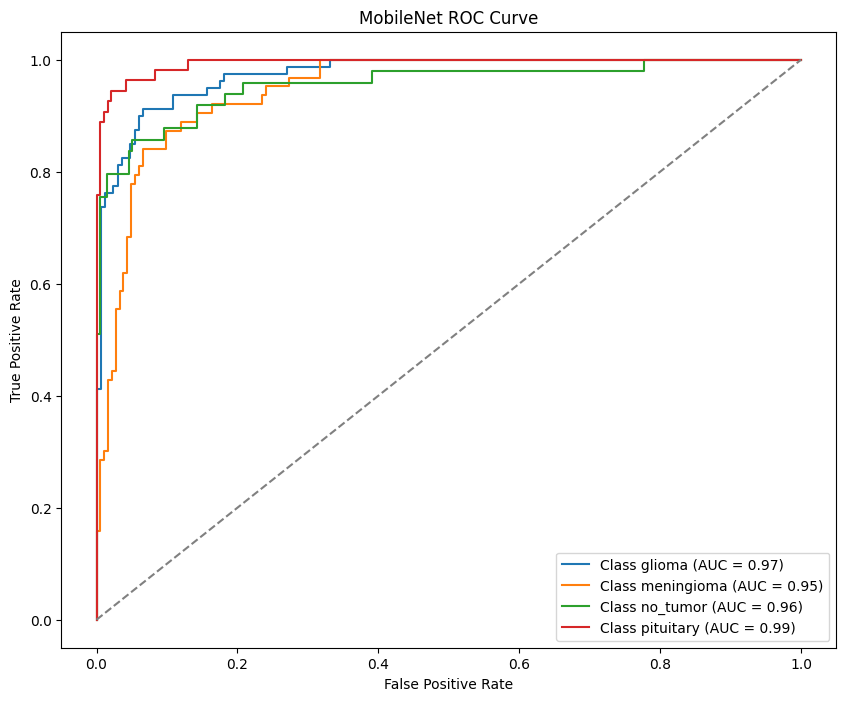

In [50]:
# 4. ROC Curve and AUC for MobileNet
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin_mobilenet = label_binarize(test_labels_encoded_mobilenet, classes=np.arange(len(LABELS)))
test_predictions_bin_mobilenet = test_predictions_mobilenet  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr_mobilenet, tpr_mobilenet, roc_auc_mobilenet = {}, {}, {}
for i in range(len(LABELS)):
    fpr_mobilenet[i], tpr_mobilenet[i], _ = roc_curve(test_labels_bin_mobilenet[:, i], test_predictions_bin_mobilenet[:, i])
    roc_auc_mobilenet[i] = auc(fpr_mobilenet[i], tpr_mobilenet[i])

# Plot ROC curve for MobileNet
plt.figure(figsize=(10, 8))
for i in range(len(LABELS)):
    plt.plot(fpr_mobilenet[i], tpr_mobilenet[i], label=f'Class {LABELS[i]} (AUC = {roc_auc_mobilenet[i]:.2f})') # Use actual label name here

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("MobileNet ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Model Comparison: InceptionV3

In [51]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D

# InceptionV3 Model Architecture
# Define the input shape for InceptionV3
IMAGE_SIZE_INCEPTION = 128 # Using the same image size for consistency

base_model_inception = InceptionV3(input_shape=(IMAGE_SIZE_INCEPTION, IMAGE_SIZE_INCEPTION, 3), include_top=False, weights='imagenet')

# Freeze all layers of the InceptionV3 base model
for layer in base_model_inception.layers:
    layer.trainable = False

# Build the final model on top of InceptionV3
model_inception = Sequential()
model_inception.add(Input(shape=(IMAGE_SIZE_INCEPTION, IMAGE_SIZE_INCEPTION, 3)))  # Input layer
model_inception.add(base_model_inception)  # Add InceptionV3 base model
model_inception.add(GlobalAveragePooling2D()) # Use GlobalAveragePooling2D for InceptionV3
model_inception.add(Dropout(0.3))  # Dropout layer for regularization
model_inception.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model_inception.add(Dropout(0.2))  # Dropout layer for regularization
model_inception.add(Dense(len(LABELS), activation='softmax'))  # Output layer with softmax activation

# Compile the InceptionV3 model
model_inception.compile(optimizer=Adam(learning_rate=0.0001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['sparse_categorical_accuracy'])

print("InceptionV3 model built and compiled.")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
InceptionV3 model built and compiled.


### Training InceptionV3 Model

In [52]:
# Train the InceptionV3 model
history_inception = model_inception.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                                        epochs=epochs, steps_per_epoch=steps)

print("InceptionV3 model training complete.")

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - loss: 1.7284 - sparse_categorical_accuracy: 0.4542
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - loss: 1.0280 - sparse_categorical_accuracy: 0.6215
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.8146 - sparse_categorical_accuracy: 0.6848
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.7385 - sparse_categorical_accuracy: 0.7099
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.5983 - sparse_categorical_accuracy: 0.7743
InceptionV3 model training complete.


### InceptionV3 Training History

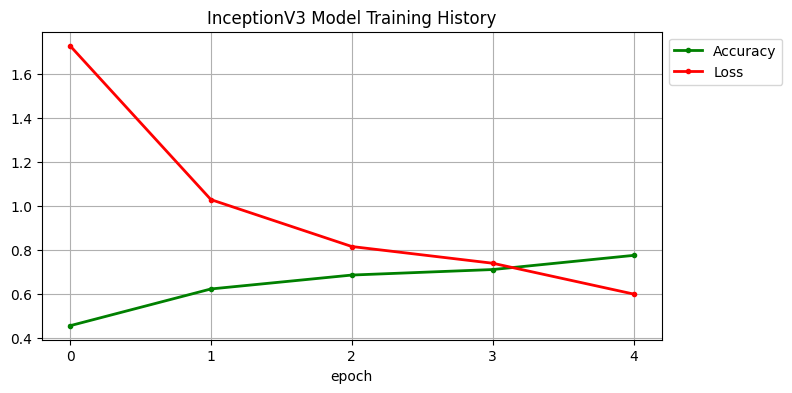

In [53]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history_inception.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_inception.history['loss'], '.r-', linewidth=2)
plt.title('InceptionV3 Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### InceptionV3 Model Evaluation

8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
InceptionV3 Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83        80
           1       0.75      0.57      0.65        63
           2       0.92      0.71      0.80        49
           3       0.84      0.94      0.89        54

    accuracy                           0.80       246
   macro avg       0.81      0.79      0.79       246
weighted avg       0.80      0.80      0.79       246


InceptionV3 Confusion Matrix:
[[74  5  0  1]
 [17 36  3  7]
 [ 7  5 35  2]
 [ 1  2  0 51]]


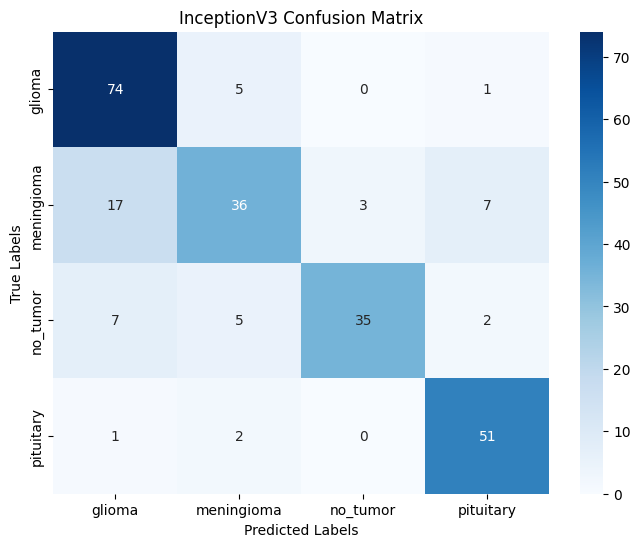

In [54]:
# 1. Prediction on test data using InceptionV3
test_images_inception = open_images(test_paths)  # Load and augment test images
test_labels_encoded_inception = encode_label(test_labels)  # Encode the test labels

# Predict using the trained InceptionV3 model
test_predictions_inception = model_inception.predict(test_images_inception)

# 2. Classification Report for InceptionV3
print("InceptionV3 Classification Report:")
print(classification_report(test_labels_encoded_inception, np.argmax(test_predictions_inception, axis=1)))

# 3. Confusion Matrix for InceptionV3
conf_matrix_inception = confusion_matrix(test_labels_encoded_inception, np.argmax(test_predictions_inception, axis=1))
print("\nInceptionV3 Confusion Matrix:")
print(conf_matrix_inception)

# Plot the InceptionV3 Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_inception, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title("InceptionV3 Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

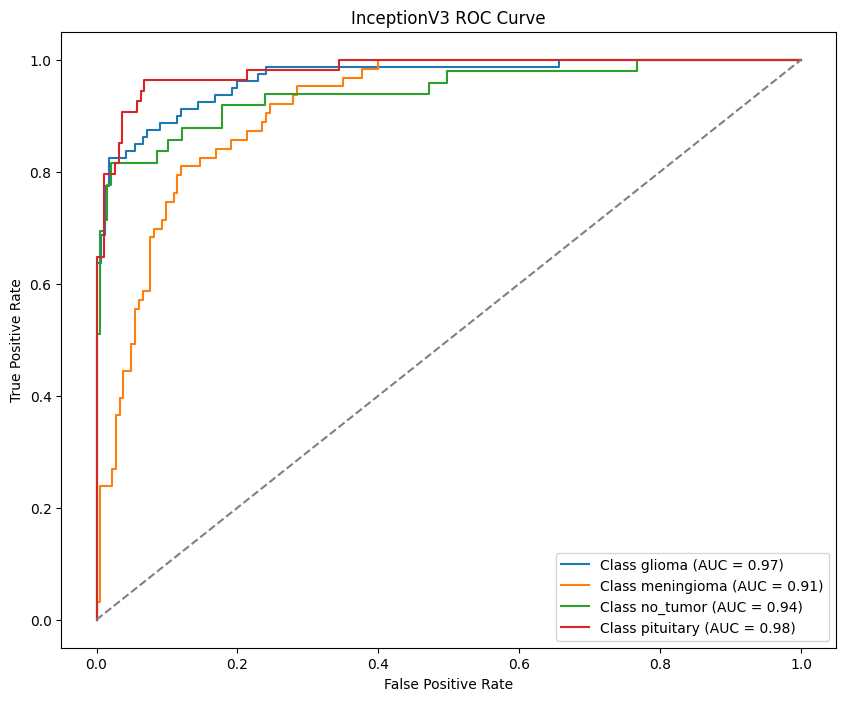

In [55]:
# 4. ROC Curve and AUC for InceptionV3
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin_inception = label_binarize(test_labels_encoded_inception, classes=np.arange(len(LABELS)))
test_predictions_bin_inception = test_predictions_inception  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr_inception, tpr_inception, roc_auc_inception = {}, {}, {}
for i in range(len(LABELS)):
    fpr_inception[i], tpr_inception[i], _ = roc_curve(test_labels_bin_inception[:, i], test_predictions_bin_inception[:, i])
    roc_auc_inception[i] = auc(fpr_inception[i], tpr_inception[i])

# Plot ROC curve for InceptionV3
plt.figure(figsize=(10, 8))
for i in range(len(LABELS)):
    plt.plot(fpr_inception[i], tpr_inception[i], label=f'Class {LABELS[i]} (AUC = {roc_auc_inception[i]:.2f})') # Use actual label name here

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("InceptionV3 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Model Comparison: EfficientNetB0

In [56]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D

# EfficientNetB0 Model Architecture
# Define the input shape for EfficientNetB0
IMAGE_SIZE_EFFICIENTNET = 128 # Using the same image size for consistency

base_model_efficientnet = EfficientNetB0(input_shape=(IMAGE_SIZE_EFFICIENTNET, IMAGE_SIZE_EFFICIENTNET, 3), include_top=False, weights='imagenet')

# Freeze all layers of the EfficientNetB0 base model
for layer in base_model_efficientnet.layers:
    layer.trainable = False

# Build the final model on top of EfficientNetB0
model_efficientnet = Sequential()
model_efficientnet.add(Input(shape=(IMAGE_SIZE_EFFICIENTNET, IMAGE_SIZE_EFFICIENTNET, 3)))  # Input layer
model_efficientnet.add(base_model_efficientnet)  # Add EfficientNetB0 base model
model_efficientnet.add(GlobalAveragePooling2D()) # Use GlobalAveragePooling2D for EfficientNetB0
model_efficientnet.add(Dropout(0.3))  # Dropout layer for regularization
model_efficientnet.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model_efficientnet.add(Dropout(0.2))  # Dropout layer for regularization
model_efficientnet.add(Dense(len(LABELS), activation='softmax'))  # Output layer with softmax activation

# Compile the EfficientNetB0 model
model_efficientnet.compile(optimizer=Adam(learning_rate=0.0001),
                          loss='sparse_categorical_crossentropy',
                          metrics=['sparse_categorical_accuracy'])

print("EfficientNetB0 model built and compiled.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 model built and compiled.


### Training EfficientNetB0 Model

In [57]:
# Train the EfficientNetB0 model
history_efficientnet = model_efficientnet.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                                              epochs=epochs, steps_per_epoch=steps)

print("EfficientNetB0 model training complete.")

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 113ms/step - loss: 1.3865 - sparse_categorical_accuracy: 0.3143
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - loss: 1.3748 - sparse_categorical_accuracy: 0.3296
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 1.3827 - sparse_categorical_accuracy: 0.3081
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 1.3783 - sparse_categorical_accuracy: 0.3164
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 1.3734 - sparse_categorical_accuracy: 0.3110
EfficientNetB0 model training complete.


### EfficientNetB0 Training History

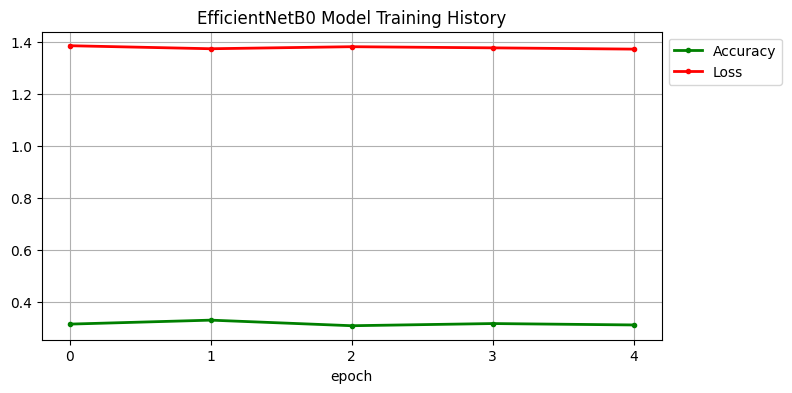

In [58]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history_efficientnet.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_efficientnet.history['loss'], '.r-', linewidth=2)
plt.title('EfficientNetB0 Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### EfficientNetB0 Model Evaluation

8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step
EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.49        80
           1       0.00      0.00      0.00        63
           2       0.00      0.00      0.00        49
           3       0.00      0.00      0.00        54

    accuracy                           0.33       246
   macro avg       0.08      0.25      0.12       246
weighted avg       0.11      0.33      0.16       246


EfficientNetB0 Confusion Matrix:
[[80  0  0  0]
 [63  0  0  0]
 [49  0  0  0]
 [54  0  0  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


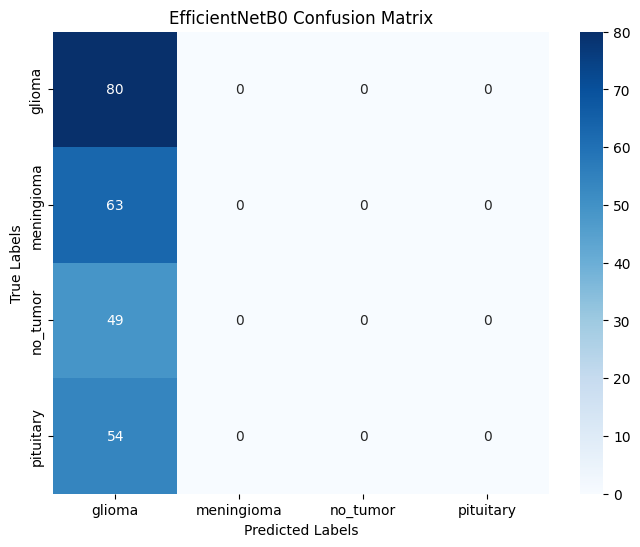

In [59]:
# 1. Prediction on test data using EfficientNetB0
test_images_efficientnet = open_images(test_paths)  # Load and augment test images
test_labels_encoded_efficientnet = encode_label(test_labels)  # Encode the test labels

# Predict using the trained EfficientNetB0 model
test_predictions_efficientnet = model_efficientnet.predict(test_images_efficientnet)

# 2. Classification Report for EfficientNetB0
print("EfficientNetB0 Classification Report:")
print(classification_report(test_labels_encoded_efficientnet, np.argmax(test_predictions_efficientnet, axis=1)))

# 3. Confusion Matrix for EfficientNetB0
conf_matrix_efficientnet = confusion_matrix(test_labels_encoded_efficientnet, np.argmax(test_predictions_efficientnet, axis=1))
print("\nEfficientNetB0 Confusion Matrix:")
print(conf_matrix_efficientnet)

# Plot the EfficientNetB0 Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_efficientnet, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

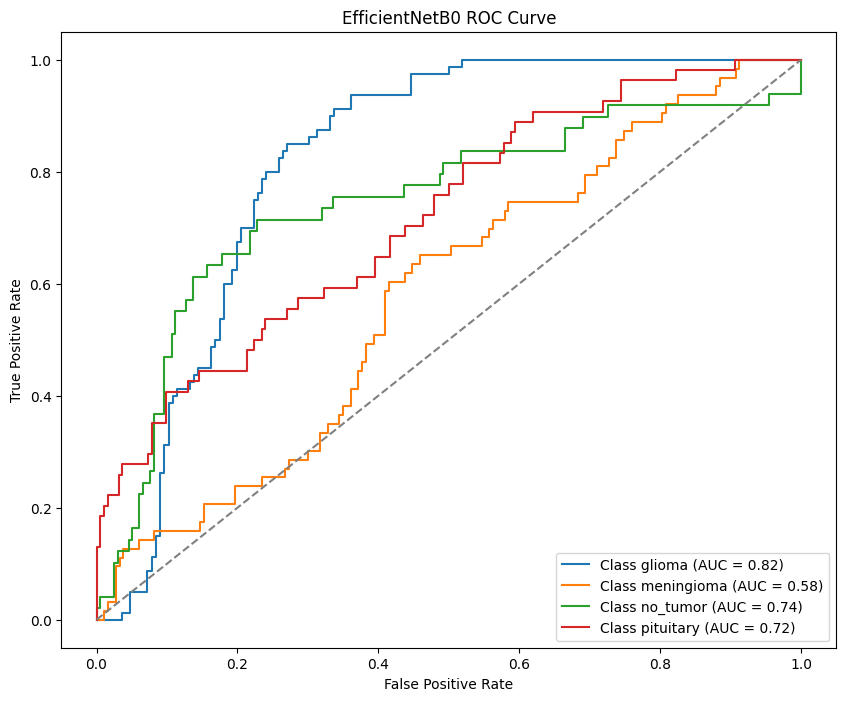

In [60]:
# 4. ROC Curve and AUC for EfficientNetB0
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin_efficientnet = label_binarize(test_labels_encoded_efficientnet, classes=np.arange(len(LABELS)))
test_predictions_bin_efficientnet = test_predictions_efficientnet  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr_efficientnet, tpr_efficientnet, roc_auc_efficientnet = {}, {}, {}
for i in range(len(LABELS)):
    fpr_efficientnet[i], tpr_efficientnet[i], _ = roc_curve(test_labels_bin_efficientnet[:, i], test_predictions_bin_efficientnet[:, i])
    roc_auc_efficientnet[i] = auc(fpr_efficientnet[i], tpr_efficientnet[i])

# Plot ROC curve for EfficientNetB0
plt.figure(figsize=(10, 8))
for i in range(len(LABELS)):
    plt.plot(fpr_efficientnet[i], tpr_efficientnet[i], label=f'Class {LABELS[i]} (AUC = {roc_auc_efficientnet[i]:.2f})') # Use actual label name here

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("EfficientNetB0 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Model Comparison: Custom CNN

In [61]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization

# Custom CNN Model Architecture
# Define the input shape for the custom CNN
IMAGE_SIZE_CUSTOM_CNN = 128 # Using the same image size for consistency

model_custom_cnn = Sequential([
    Input(shape=(IMAGE_SIZE_CUSTOM_CNN, IMAGE_SIZE_CUSTOM_CNN, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(LABELS), activation='softmax')
])

# Compile the Custom CNN model
model_custom_cnn.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['sparse_categorical_accuracy'])

print("Custom CNN model built and compiled.")

Custom CNN model built and compiled.


### Training Custom CNN Model

In [62]:
# Train the Custom CNN model
history_custom_cnn = model_custom_cnn.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                                            epochs=epochs, steps_per_epoch=steps)

print("Custom CNN model training complete.")

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - loss: 0.9498 - sparse_categorical_accuracy: 0.6988
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - loss: 0.6335 - sparse_categorical_accuracy: 0.7743
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.5964 - sparse_categorical_accuracy: 0.7910
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.4883 - sparse_categorical_accuracy: 0.8197
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.4273 - sparse_categorical_accuracy: 0.8448
Custom CNN model training complete.


### Custom CNN Training History

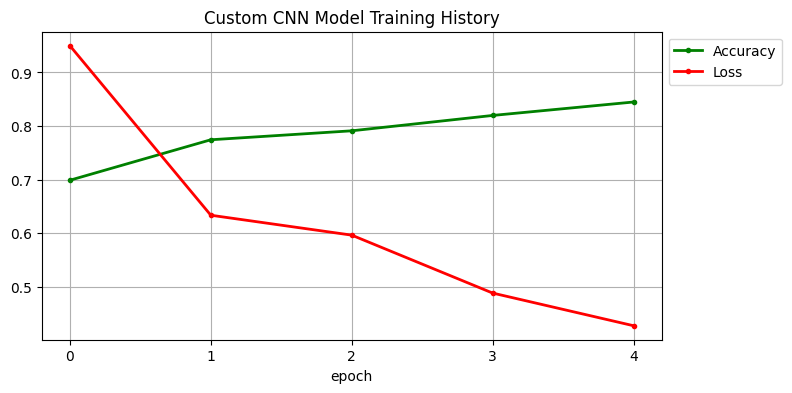

In [63]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history_custom_cnn.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history_custom_cnn.history['loss'], '.r-', linewidth=2)
plt.title('Custom CNN Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### Custom CNN Model Evaluation

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step
Custom CNN Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        80
           1       0.30      0.87      0.44        63
           2       1.00      0.16      0.28        49
           3       0.50      0.48      0.49        54

    accuracy                           0.36       246
   macro avg       0.45      0.38      0.30       246
weighted avg       0.38      0.36      0.28       246


Custom CNN Confusion Matrix:
[[ 0 72  0  8]
 [ 0 55  0  8]
 [ 0 31  8 10]
 [ 0 28  0 26]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


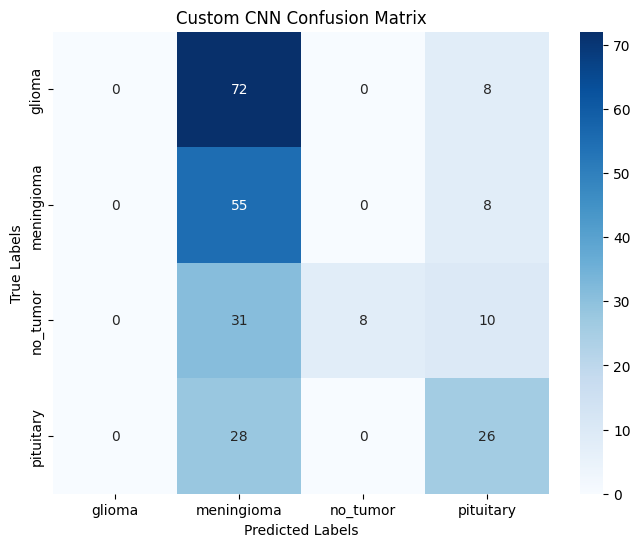

In [64]:
# 1. Prediction on test data using Custom CNN
test_images_custom_cnn = open_images(test_paths)  # Load and augment test images
test_labels_encoded_custom_cnn = encode_label(test_labels)  # Encode the test labels

# Predict using the trained Custom CNN model
test_predictions_custom_cnn = model_custom_cnn.predict(test_images_custom_cnn)

# 2. Classification Report for Custom CNN
print("Custom CNN Classification Report:")
print(classification_report(test_labels_encoded_custom_cnn, np.argmax(test_predictions_custom_cnn, axis=1)))

# 3. Confusion Matrix for Custom CNN
conf_matrix_custom_cnn = confusion_matrix(test_labels_encoded_custom_cnn, np.argmax(test_predictions_custom_cnn, axis=1))
print("\nCustom CNN Confusion Matrix:")
print(conf_matrix_custom_cnn)

# Plot the Custom CNN Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_custom_cnn, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

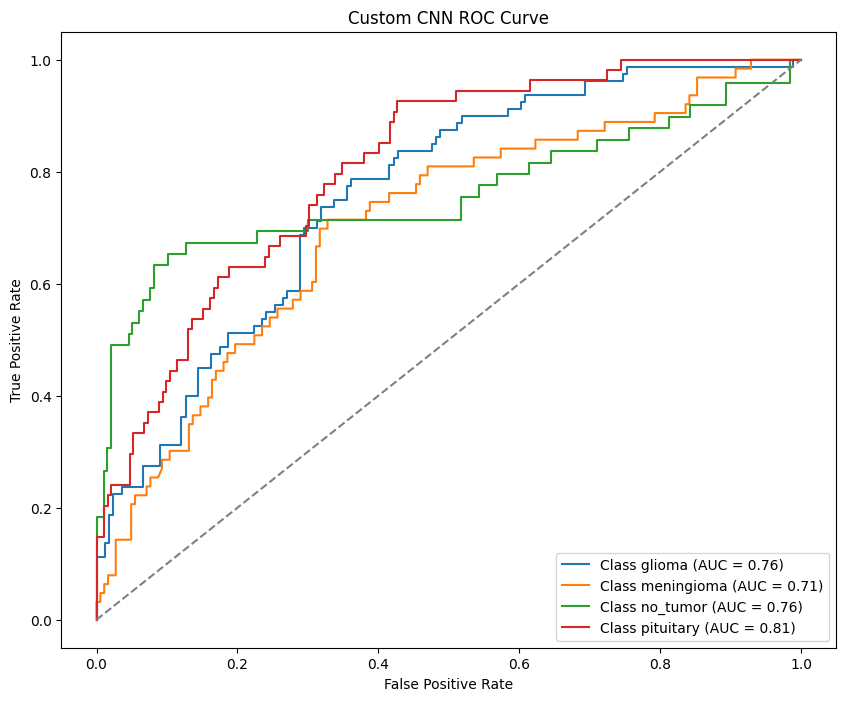

In [65]:
# 4. ROC Curve and AUC for Custom CNN
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin_custom_cnn = label_binarize(test_labels_encoded_custom_cnn, classes=np.arange(len(LABELS)))
test_predictions_bin_custom_cnn = test_predictions_custom_cnn  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr_custom_cnn, tpr_custom_cnn, roc_auc_custom_cnn = {}, {}, {}
for i in range(len(LABELS)):
    fpr_custom_cnn[i], tpr_custom_cnn[i], _ = roc_curve(test_labels_bin_custom_cnn[:, i], test_predictions_bin_custom_cnn[:, i])
    roc_auc_custom_cnn[i] = auc(fpr_custom_cnn[i], tpr_custom_cnn[i])

# Plot ROC curve for Custom CNN
plt.figure(figsize=(10, 8))
for i in range(len(LABELS)):
    plt.plot(fpr_custom_cnn[i], tpr_custom_cnn[i], label=f'Class {LABELS[i]} (AUC = {roc_auc_custom_cnn[i]:.2f})') # Use actual label name here

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("Custom CNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Model Comparison Summary

In [66]:
import pandas as pd

# Collect metrics from each model
model_names = ['VGG16', 'ResNet50', 'MobileNet', 'InceptionV3', 'Custom CNN']

accuracies = [
    history.history['sparse_categorical_accuracy'][-1] if history else 0,
    history_resnet.history['sparse_categorical_accuracy'][-1] if history_resnet else 0,
    history_mobilenet.history['sparse_categorical_accuracy'][-1] if history_mobilenet else 0,
    history_inception.history['sparse_categorical_accuracy'][-1] if history_inception else 0,
    history_custom_cnn.history['sparse_categorical_accuracy'][-1] if history_custom_cnn else 0
]

losses = [
    history.history['loss'][-1] if history else 0,
    history_resnet.history['loss'][-1] if history_resnet else 0,
    history_mobilenet.history['loss'][-1] if history_mobilenet else 0,
    history_inception.history['loss'][-1] if history_inception else 0,
    history_custom_cnn.history['loss'][-1] if history_custom_cnn else 0
]

# Assuming roc_auc dictionaries are available for each model from previous cells
roc_aucs_data = {
    'VGG16': roc_auc,
    'ResNet50': roc_auc_resnet,
    'MobileNet': roc_auc_mobilenet,
    'InceptionV3': roc_auc_inception,
    'Custom CNN': roc_auc_custom_cnn
}

# Create a DataFrame to display comparison
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Final Training Accuracy': accuracies,
    'Final Training Loss': losses
})

print("\n--- Model Training Performance ---")
display(comparison_df)

# Also display test evaluation metrics (accuracy from classification report, and average AUC)

# For VGG16 (original model)
report_vgg16 = classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1), output_dict=True)
accuracy_vgg16 = report_vgg16['accuracy']
avg_auc_vgg16 = np.mean(list(roc_aucs_data['VGG16'].values()))

# For ResNet50
report_resnet = classification_report(test_labels_encoded_resnet, np.argmax(test_predictions_resnet, axis=1), output_dict=True)
accuracy_resnet = report_resnet['accuracy']
avg_auc_resnet = np.mean(list(roc_aucs_data['ResNet50'].values()))

# For MobileNet
report_mobilenet = classification_report(test_labels_encoded_mobilenet, np.argmax(test_predictions_mobilenet, axis=1), output_dict=True)
accuracy_mobilenet = report_mobilenet['accuracy']
avg_auc_mobilenet = np.mean(list(roc_aucs_data['MobileNet'].values()))

# For InceptionV3
report_inception = classification_report(test_labels_encoded_inception, np.argmax(test_predictions_inception, axis=1), output_dict=True)
accuracy_inception = report_inception['accuracy']
avg_auc_inception = np.mean(list(roc_aucs_data['InceptionV3'].values()))

# For Custom CNN
report_custom_cnn = classification_report(test_labels_encoded_custom_cnn, np.argmax(test_predictions_custom_cnn, axis=1), output_dict=True)
accuracy_custom_cnn = report_custom_cnn['accuracy']
avg_auc_custom_cnn = np.mean(list(roc_aucs_data['Custom CNN'].values()))

eval_comparison_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': [accuracy_vgg16, accuracy_resnet, accuracy_mobilenet, accuracy_inception, accuracy_custom_cnn],
    'Average Test AUC': [avg_auc_vgg16, avg_auc_resnet, avg_auc_mobilenet, avg_auc_inception, avg_auc_custom_cnn]
})

print("\n--- Model Test Evaluation Performance ---")
display(eval_comparison_df)

# Identify the best model based on a chosen metric (e.g., test accuracy)
best_model_row = eval_comparison_df.loc[eval_comparison_df['Test Accuracy'].idxmax()]
print(f"\nBest performing model based on Test Accuracy: {best_model_row['Model']} with Accuracy: {best_model_row['Test Accuracy']:.4f}")


--- Model Training Performance ---


,Model,Final Training Accuracy,Final Training Loss
0,VGG16,0.957612,0.121901
1,ResNet50,0.414328,1.293414
2,MobileNet,0.819104,0.483852
3,InceptionV3,0.774328,0.598256
4,Custom CNN,0.844776,0.427338



--- Model Test Evaluation Performance ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Test Accuracy,Average Test AUC
0,VGG16,0.918699,0.986477
1,ResNet50,0.516260,0.813121
2,MobileNet,0.853659,0.967983
3,InceptionV3,0.796748,0.951703
4,Custom CNN,0.361789,0.758561



Best performing model based on Test Accuracy: VGG16 with Accuracy: 0.9187


In [67]:
# Save the entire model
model.save('model.h5')

In [68]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('model.h5')

In [69]:
# MRI Tumor Detection System

In [75]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = LABELS # Use the globally defined LABELS

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'no_tumor': # Note: 'no_tumor' is the label in your dataset
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%) - Image: {os.path.basename(img_path)}")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step


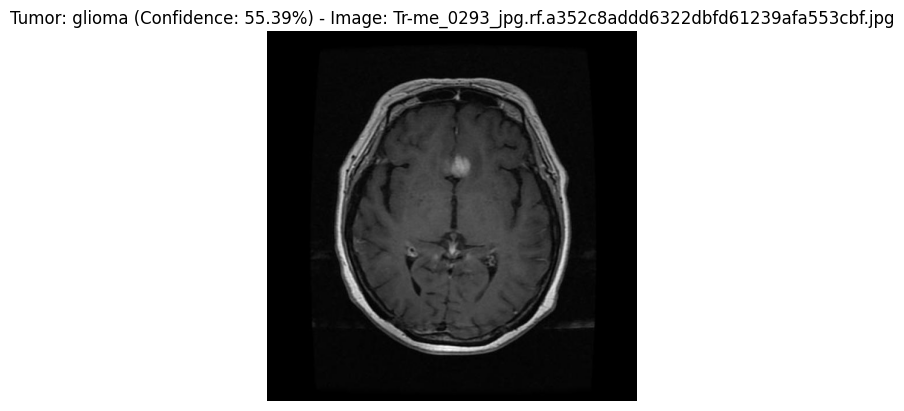

In [76]:
# Example usage
# Using a path from the loaded test_paths to ensure it exists
image_path = test_paths[0] # Pick the first image from the shuffled test set
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


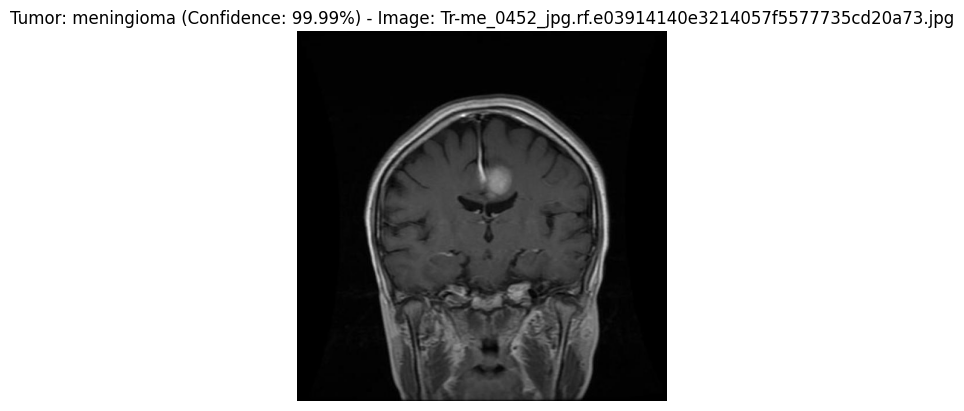

In [77]:
image_path = test_paths[49]
detect_and_display(image_path, model)

Path being used for detection: /content/drive/MyDrive/Tumour-20260617T101606Z-3-001/Tumour/test/meningioma/Tr-me_0293_jpg.rf.a352c8addd6322dbfd61239afa553cbf.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


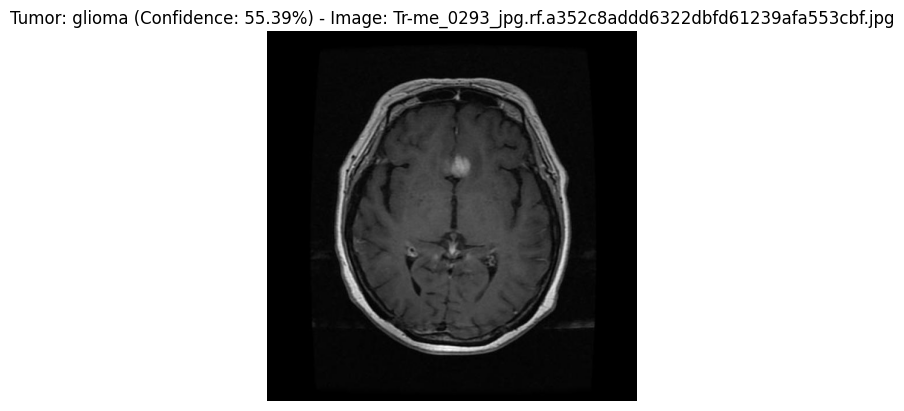

In [78]:
# Print the actual path to verify
print(f"Path being used for detection: {test_paths[0]}")

# Retry the example usage with the verified path
detect_and_display(test_paths[0], model)

---